# ₿ Bitcoin Price Predictor: ML Project Tasks 1–6

**Semester 5 · Machine Learning Project**

This notebook covers every required task for the Bitcoin price predictor. The trained model is also served by the web app (`app.py`).

| # | Task | Section |
|---|------|---------|
| 1 | Problem definition & dataset exploration | [Task 1](#task1) |
| 2 | Data cleaning & pre-processing | [Task 2](#task2) |
| 3 | Model creation (scikit-learn **and** from scratch in NumPy) | [Task 3](#task3) |
| 4 | Model evaluation & diagnosis (underfitting vs overfitting) | [Task 4](#task4) |
| 5 | Advanced models, cross-validation & hyperparameter tuning | [Task 5](#task5) |
| 6 | Visualization of metrics & performance graphs | [Task 6](#task6) |

Outputs written by this notebook:
`reports/data_dictionary.csv`, `bitcoin_processed.csv`, `linear_model.pkl`, `tuned_rf.pkl`, `evaluation.json`, and all charts in `reports/figures/`.

In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score, confusion_matrix,
                             classification_report, roc_curve, roc_auc_score, make_scorer)

from my_models import MyLinearRegression, MyLogisticRegression

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.width", 160)

DATA_PATH = Path("../DATA/bitcoin_data.csv")
FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DATE = "2025-01-01"   # train: 2012-2024, test: 2025-2026 (same test period as the web app)
SEED = 42

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
ORANGE, VIOLET, GREY, GREEN, RED = "#f7931a", "#7b5cff", "#8d93a8", "#2fa36b", "#d64545"

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

C:\Users\Soham\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


<a id="task1"></a>
# Task 1: Problem Definition & Dataset Exploration

## 1a. The machine-learning problem

| Item | Definition |
|------|------------|
| **Problem type** | Supervised learning, **regression** on a **time series** |
| **Question** | Given Bitcoin's price history up to day *t*, what will the **closing price on day t + 1** be? |
| **Target variable** | Next-day log return $r_{t+1} = \ln(C_{t+1} / C_t)$; the predicted price is $\hat C_{t+1} = C_t \cdot e^{\hat r_{t+1}}$ |
| **Secondary view** | **Direction** (1 = price goes up, 0 = goes down), derived from the sign of the predicted return. It lets us report classification metrics (confusion matrix, precision, recall, F1, ROC-AUC). |
| **Inputs** | Only information available at the end of day *t* (past prices and volume). No look-ahead. |

**Why predict the return instead of the raw price?** The price rose from about \$4 to more than \$100,000. A model trained on raw prices has to extrapolate to levels it has never seen. Tree models can't do that at all: they cap at the highest training value. Returns are roughly stationary (similar scale in every year), so the same patterns apply in 2013 and in 2026.

## 1b. Dataset dimensions & schema

In [2]:
t0 = time.time()
raw = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH} in {time.time() - t0:.1f} s")
print(f"Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}")
raw.head()

Loaded ..\DATA\bitcoin_data.csv in 2.7 s
Rows: 7,616,181   Columns: 6


,Timestamp,Open,High,Low,Close,Volume
0,1325376060,4.5800,4.5800,4.5800,4.5800,0.0000
1,1325376120,4.5800,4.5800,4.5800,4.5800,0.0000
2,1325376180,4.5800,4.5800,4.5800,4.5800,0.0000
3,1325376240,4.5800,4.5800,4.5800,4.5800,0.0000
4,1325376300,4.5800,4.5800,4.5800,4.5800,0.0000


In [3]:
print("Data types:")
print(raw.dtypes, "\n")
print("Missing values per column:")
print(raw.isnull().sum(), "\n")
print("Duplicate rows:", raw.duplicated().sum())
print("Duplicate timestamps:", raw["Timestamp"].duplicated().sum())
raw.describe().T

Data types:
Timestamp      int64
Open         float64
High         float64
Low          float64
Close        float64
Volume       float64
dtype: object 

Missing values per column:
Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64 



Duplicate rows: 0


Duplicate timestamps: 0


,count,mean,std,min,25%,50%,75%,max
Timestamp,"7,616,181.0000","1,553,861,460.0000","131,916,133.1767","1,325,376,060.0000","1,439,618,760.0000","1,553,861,460.0000","1,668,104,160.0000","1,782,346,860.0000"
Open,"7,616,181.0000","23,423.5949","31,306.4011",3.8000,455.5700,"7,983.1500","37,991.1300","126,202.0000"
High,"7,616,181.0000","23,431.7722","31,314.7948",3.8000,455.7200,"7,988.5000","38,011.8400","126,272.0000"
Low,"7,616,181.0000","23,415.2460","31,297.9528",3.8000,455.4100,"7,977.8300","37,969.7600","126,158.0000"
Close,"7,616,181.0000","23,423.6141","31,306.4250",3.8000,455.5600,"7,982.7100","37,990.2000","126,202.0000"
Volume,"7,616,181.0000",4.9943,21.6579,0.0000,0.0215,0.4493,2.7988,"5,853.8522"


## 1c. Data dictionary

In [4]:
descriptions = {
    "Timestamp": ("Start of the 1-minute interval (Unix epoch, UTC)", "seconds"),
    "Open":      ("First traded price in the minute", "USD"),
    "High":      ("Highest traded price in the minute", "USD"),
    "Low":       ("Lowest traded price in the minute", "USD"),
    "Close":     ("Last traded price in the minute", "USD"),
    "Volume":    ("Amount of BTC traded in the minute", "BTC"),
}
data_dict = pd.DataFrame({
    "Column": raw.columns,
    "Type": raw.dtypes.astype(str).values,
    "Group": ["Time", "Price", "Price", "Price", "Price (target source)", "Activity"],
    "Description": [descriptions[c][0] for c in raw.columns],
    "Unit": [descriptions[c][1] for c in raw.columns],
    "Non-null": raw.notnull().sum().values,
    "Unique values (cardinality)": raw.nunique().values,
    "Min": raw.min().values,
    "Max": raw.max().values,
})
Path("reports").mkdir(exist_ok=True)
data_dict.to_csv("reports/data_dictionary.csv", index=False)
data_dict

,Column,Type,Group,Description,Unit,Non-null,Unique values (cardinality),Min,Max
0,Timestamp,int64,Time,"Start of the 1-minute interval (Unix epoch, UTC)",seconds,7616181,7616181,"1,325,376,060.0000","1,782,346,860.0000"
1,Open,float64,Price,First traded price in the minute,USD,7616181,1786431,3.8000,"126,202.0000"
2,High,float64,Price,Highest traded price in the minute,USD,7616181,1750669,3.8000,"126,272.0000"
3,Low,float64,Price,Lowest traded price in the minute,USD,7616181,1761877,3.8000,"126,158.0000"
4,Close,float64,Price (target source),Last traded price in the minute,USD,7616181,1778803,3.8000,"126,202.0000"
5,Volume,float64,Activity,Amount of BTC traded in the minute,BTC,7616181,5503448,0.0000,"5,853.8522"


## 1d. Time coverage & gaps

In [5]:
ts = raw["Timestamp"].to_numpy()
step = np.diff(ts)
expected_minutes = (ts[-1] - ts[0]) // 60 + 1
missing_minutes = int(np.sum(step // 60 - 1))
start, end = pd.to_datetime(ts[0], unit="s"), pd.to_datetime(ts[-1], unit="s")

print(f"Period             : {start}  ->  {end}  ({(end - start).days:,} days)")
print(f"Expected minutes   : {expected_minutes:,}")
print(f"Rows present       : {len(raw):,}")
print(f"Missing minutes    : {missing_minutes:,}  ({missing_minutes / expected_minutes:.3%})")
print(f"Gaps (> 1 minute)  : {(step > 60).sum():,}   longest gap: {step.max() / 3600:.1f} hours")
print(f"Zero-volume minutes: {(raw['Volume'] == 0).mean():.2%}  (no trades in that minute)")
print(f"Price range        : ${raw['Low'].min():,.2f}  ->  ${raw['High'].max():,.2f}  "
      f"({raw['High'].max() / raw['Low'].min():,.0f}x)")

Period             : 2012-01-01 00:01:00  ->  2026-06-25 00:21:00  (5,289 days)
Expected minutes   : 7,616,181
Rows present       : 7,616,181
Missing minutes    : 0  (0.000%)
Gaps (> 1 minute)  : 0   longest gap: 0.0 hours
Zero-volume minutes: 17.23%  (no trades in that minute)
Price range        : $3.80  ->  $126,272.00  (33,229x)


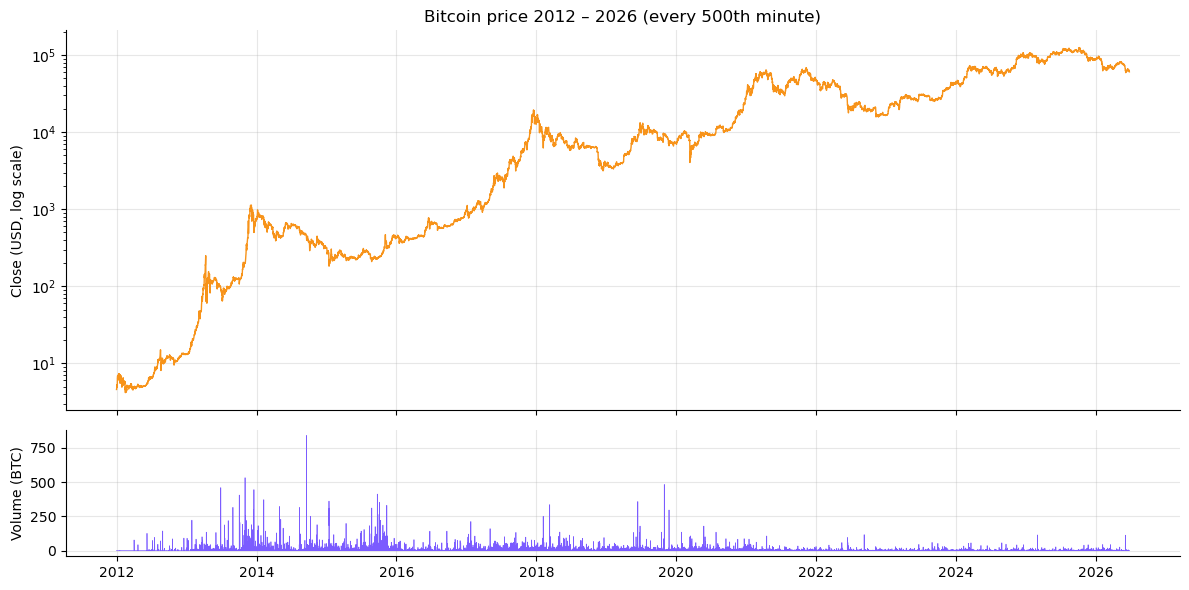

In [6]:
dt_index = pd.to_datetime(raw["Timestamp"], unit="s")
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax[0].plot(dt_index[::500], raw["Close"][::500], color=ORANGE, lw=1)
ax[0].set_yscale("log"); ax[0].set_ylabel("Close (USD, log scale)")
ax[0].set_title("Bitcoin price 2012 – 2026 (every 500th minute)")
ax[1].plot(dt_index[::500], raw["Volume"][::500], color=VIOLET, lw=0.5)
ax[1].set_ylabel("Volume (BTC)")
savefig("task1_price_history")

## 1e. Critical characteristics & challenges

| # | Challenge | Evidence | How we handle it |
|---|-----------|----------|------------------|
| 1 | **Huge scale range** | Price goes from about \$4 to more than \$120k (roughly 30,000×) | Model **log returns**, not raw prices; standardise features |
| 2 | **Non-stationary time series** | The trend and volatility change over the years | **Chronological** train/test split and **time-series** cross-validation (no random shuffling, which would leak future data) |
| 3 | **Heavy-tailed returns / outliers** | Single-day moves of ±20–40% (for example March 2020) | **IQR capping** of features (Task 2b) |
| 4 | **Very noisy target** | Daily returns are close to a random walk | Compare every model with a **naive baseline**; expect a low R² on returns |
| 5 | **Zero-volume minutes** | No minutes are missing, but about 17% of minutes have no trades (volume 0, price unchanged) | Resample to **daily** candles, where every day has trades; the pipeline would still forward-fill an empty day |
| 6 | **7.6 M rows** | Too fine-grained and noisy for a daily forecast | Resample to about 5,300 daily rows |
| 7 | **No categorical columns** | All columns are numeric | We create one categorical feature (day of week) and one-hot encode it (Task 2d) |
| 8 | **Direction classes are balanced** | Up days ≈ down days (see Task 2f) | Accuracy is meaningful for direction, but we still report precision, recall and F1 |

<a id="task2"></a>
# Task 2: Data Cleaning & Pre-processing

## 2a. Missing values & resampling to daily candles

Section 1d showed the raw file has **no NaN cells and no missing minutes**. The pipeline is still written to handle missing data safely:
we aggregate minutes into daily OHLCV candles, and if a whole day were missing, we would **forward-fill** its price.

> Why not the **median**? Median imputation is for independent rows (for example customers). In a time series, the best estimate for a missing day's price is the **last known price**. Filling in the median of 14 years of prices (about \$8k) on a day when Bitcoin traded at \$60k would be badly wrong.

In [7]:
raw["Datetime"] = pd.to_datetime(raw["Timestamp"], unit="s")
daily = (raw.set_index("Datetime")
            .resample("D")
            .agg({"Open": "first", "High": "max", "Low": "min", "Close": "last", "Volume": "sum"}))

empty_days = daily["Close"].isna().sum()
print("Daily candles     :", len(daily))
print("Empty days (NaN)  :", empty_days)
daily["Close"] = daily["Close"].ffill()
for col in ["Open", "High", "Low"]:
    daily[col] = daily[col].fillna(daily["Close"])
daily["Volume"] = daily["Volume"].fillna(0)
print("NaN after cleaning:", int(daily.isna().sum().sum()))

del raw, dt_index   # free ~400 MB
daily.tail()

Daily candles     : 5290
Empty days (NaN)  : 0
NaN after cleaning: 0


,Open,High,Low,Close,Volume
Datetime,,,,,
2026-06-21,"64,225.9900","64,522.0000","63,197.2300","63,237.1800",551.0967
2026-06-22,"63,237.1700","65,555.1300","63,237.1700","63,948.9600","1,437.3907"
2026-06-23,"63,948.9500","64,199.8500","61,860.0100","62,651.4300","1,351.7402"
2026-06-24,"62,651.4300","63,137.0000","59,018.4500","60,987.0000","2,180.3762"
2026-06-25,"60,981.4500","61,068.3600","60,854.3900","60,869.9700",11.8913


## 2b. Feature engineering (past information only)

Every feature for day *t* uses data up to and including day *t*, so there is no look-ahead leakage.

In [8]:
close = daily["Close"]
logret = np.log(close).diff()

feat = pd.DataFrame(index=daily.index)
for lag in [1, 2, 3, 7, 14, 30]:                       # recent daily returns
    feat[f"Ret_Lag_{lag}"] = logret.shift(lag - 1)
for w in [7, 30, 90]:                                  # distance from moving averages
    feat[f"Close_to_MA_{w}"] = close / close.rolling(w).mean() - 1
for w in [7, 30]:                                      # realised volatility
    feat[f"Vol_{w}"] = logret.rolling(w).std()
feat["Mom_30"] = np.log(close / close.shift(30))       # 30-day momentum
feat["HL_Range"] = (daily["High"] - daily["Low"]) / close          # intraday range (% of price)
feat["Volume_Change"] = np.log1p(daily["Volume"]).diff()           # change in trading activity
feat["DayOfWeek"] = daily.index.day_name()                         # categorical (encoded in 2d)

target = logret.shift(-1).rename("Target")          # next-day log return
data = pd.concat([feat, target, close.rename("Close")], axis=1)
data = data.replace([np.inf, -np.inf], np.nan).dropna()
print("Modelling rows:", len(data), "  from", data.index.min().date(), "to", data.index.max().date())

CONT_FEATURES = [c for c in feat.columns if c != "DayOfWeek"]
is_train = data.index < SPLIT_DATE
print(f"Train rows: {is_train.sum():,}   Test rows: {(~is_train).sum():,}")

Modelling rows: 5200   from 2012-03-30 to 2026-06-24
Train rows: 4,660   Test rows: 540


## 2c. Outlier detection & capping (IQR method)

$IQR = Q_3 - Q_1$, lower bound $= Q_1 - 1.5 \cdot IQR$, upper bound $= Q_3 + 1.5 \cdot IQR$.
Values outside the bounds are **clipped**, not deleted, so no rows are lost.

The bounds are computed on the **training period only** and then applied to the test period. Computing them on all the data would leak information from the future. We cap the **features** only. The target (real next-day return) is left as-is, because we must be evaluated on what really happened.

In [9]:
q1 = data.loc[is_train, CONT_FEATURES].quantile(0.25)
q3 = data.loc[is_train, CONT_FEATURES].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

before = data[CONT_FEATURES].copy()
data[CONT_FEATURES] = data[CONT_FEATURES].clip(lower=lower, upper=upper, axis=1)

outlier_report = pd.DataFrame({
    "Lower bound": lower, "Upper bound": upper,
    "% clipped (all rows)": ((before < lower) | (before > upper)).mean() * 100,
}).sort_values("% clipped (all rows)", ascending=False)
outlier_report

,Lower bound,Upper bound,% clipped (all rows)
Ret_Lag_1,-0.0577,0.0634,9.4615
Ret_Lag_2,-0.0578,0.0635,9.4615
Ret_Lag_3,-0.0578,0.0635,9.4615
Ret_Lag_7,-0.0578,0.0636,9.4615
Ret_Lag_14,-0.0578,0.0636,9.4615
Ret_Lag_30,-0.0579,0.0637,9.4231
Close_to_MA_7,-0.0905,0.1043,6.5962
HL_Range,-0.0349,0.1256,6.1154
Close_to_MA_30,-0.2436,0.2919,4.8269
Vol_30,-0.0057,0.0715,4.6538


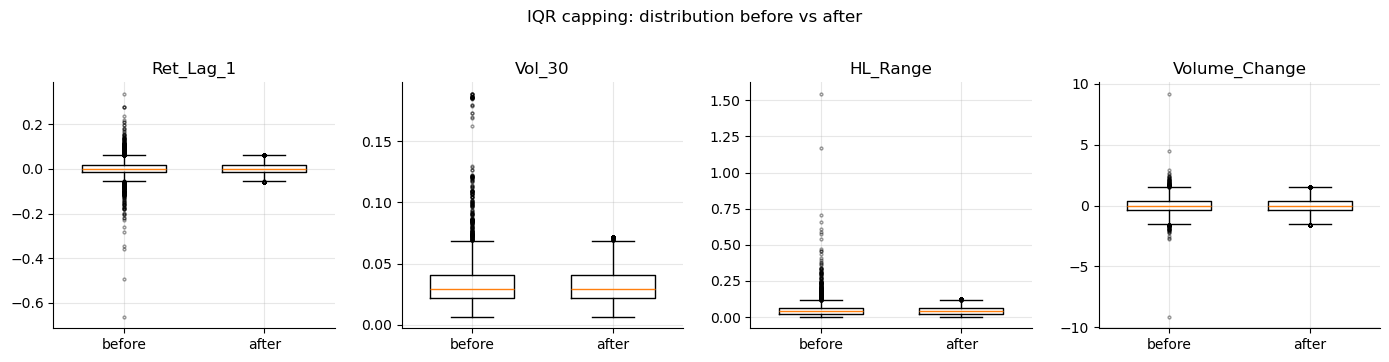

In [10]:
show = ["Ret_Lag_1", "Vol_30", "HL_Range", "Volume_Change"]
fig, axes = plt.subplots(1, len(show), figsize=(14, 3.5))
for ax, col in zip(axes, show):
    ax.boxplot([before[col], data[col]], tick_labels=["before", "after"], widths=0.6,
               flierprops={"markersize": 2, "alpha": 0.4})
    ax.set_title(col)
fig.suptitle("IQR capping: distribution before vs after", y=1.02)
savefig("task2_iqr_capping")

## 2d. Categorical encoding

Bitcoin data has no text columns, so we engineered `DayOfWeek` (7 categories).
It is **one-hot encoded** with `pd.get_dummies(drop_first=True)`: 7 categories become 6 binary columns. Friday is the dropped reference, which avoids the dummy-variable trap (perfect multicollinearity).

In [11]:
dummies = pd.get_dummies(data["DayOfWeek"], prefix="DOW", drop_first=True).astype(int)
data = pd.concat([data.drop(columns="DayOfWeek"), dummies], axis=1)
DUMMY_FEATURES = list(dummies.columns)
FEATURES = CONT_FEATURES + DUMMY_FEATURES
print("One-hot columns:", DUMMY_FEATURES)
print("Total features :", len(FEATURES))
data[DUMMY_FEATURES].head()

One-hot columns: ['DOW_Monday', 'DOW_Saturday', 'DOW_Sunday', 'DOW_Thursday', 'DOW_Tuesday', 'DOW_Wednesday']
Total features : 20


,DOW_Monday,DOW_Saturday,DOW_Sunday,DOW_Thursday,DOW_Tuesday,DOW_Wednesday
Datetime,,,,,,
2012-03-30,0,0,0,0,0,0
2012-03-31,0,1,0,0,0,0
2012-04-01,0,0,1,0,0,0
2012-04-02,1,0,0,0,0,0
2012-04-03,0,0,0,0,1,0


## 2e. Feature scaling (standardisation)

$z = (x - \mu) / \sigma$ is applied to the continuous features. The scaler is **fit on training rows only**.
The 0/1 dummy columns are left unscaled. After scaling, every training feature has mean 0 and standard deviation 1.

In [12]:
scaler = StandardScaler().fit(data.loc[is_train, CONT_FEATURES])
data[CONT_FEATURES] = scaler.transform(data[CONT_FEATURES])

check = pd.DataFrame({"Train mean": data.loc[is_train, CONT_FEATURES].mean(),
                      "Train std": data.loc[is_train, CONT_FEATURES].std(ddof=0)})
check.round(4)

,Train mean,Train std
Ret_Lag_1,0.0000,1.0000
Ret_Lag_2,0.0000,1.0000
Ret_Lag_3,-0.0000,1.0000
Ret_Lag_7,-0.0000,1.0000
Ret_Lag_14,-0.0000,1.0000
Ret_Lag_30,0.0000,1.0000
Close_to_MA_7,-0.0000,1.0000
Close_to_MA_30,0.0000,1.0000
Close_to_MA_90,0.0000,1.0000
Vol_7,-0.0000,1.0000


## 2f. Exploratory data analysis

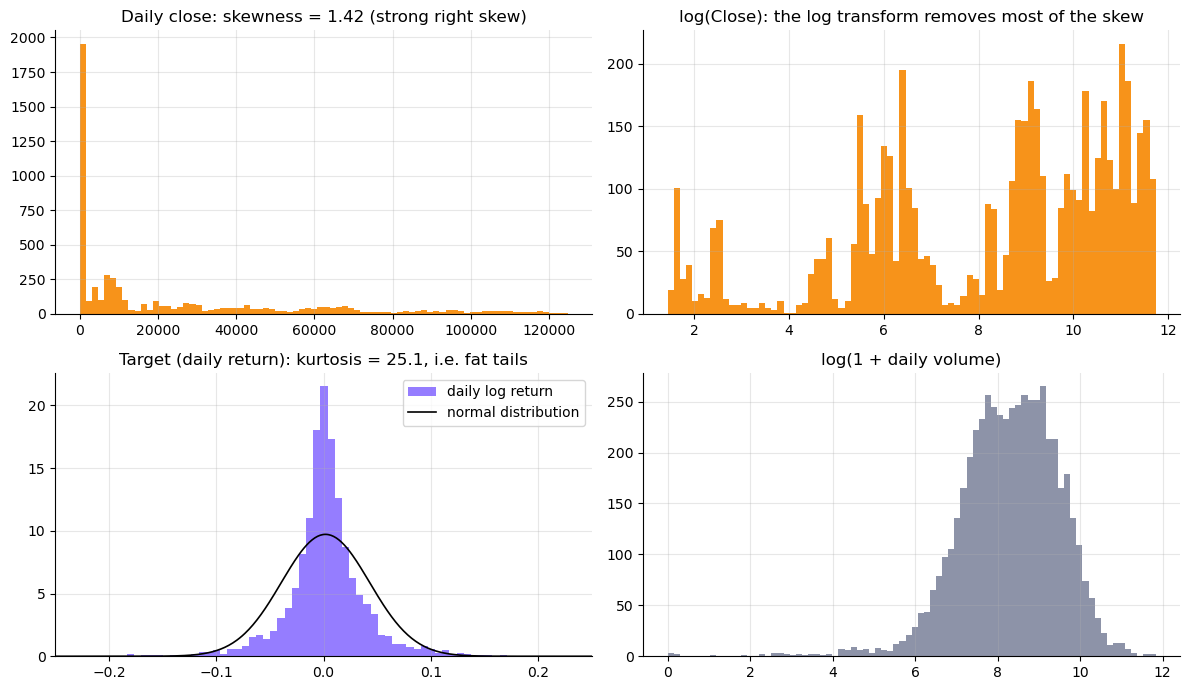

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0, 0].hist(daily["Close"], bins=80, color=ORANGE)
ax[0, 0].set_title(f"Daily close: skewness = {daily['Close'].skew():.2f} (strong right skew)")
ax[0, 1].hist(np.log(daily["Close"]), bins=80, color=ORANGE)
ax[0, 1].set_title("log(Close): the log transform removes most of the skew")
r = logret.dropna()
ax[1, 0].hist(r, bins=150, color=VIOLET, density=True, alpha=0.8, label="daily log return")
xs = np.linspace(-0.25, 0.25, 400)
ax[1, 0].plot(xs, np.exp(-(xs - r.mean()) ** 2 / (2 * r.var())) / np.sqrt(2 * np.pi * r.var()),
              color="black", lw=1.2, label="normal distribution")
ax[1, 0].set_xlim(-0.25, 0.25); ax[1, 0].legend()
ax[1, 0].set_title(f"Target (daily return): kurtosis = {r.kurt():.1f}, i.e. fat tails")
ax[1, 1].hist(np.log1p(daily["Volume"]), bins=80, color=GREY)
ax[1, 1].set_title("log(1 + daily volume)")
savefig("task2_histograms")

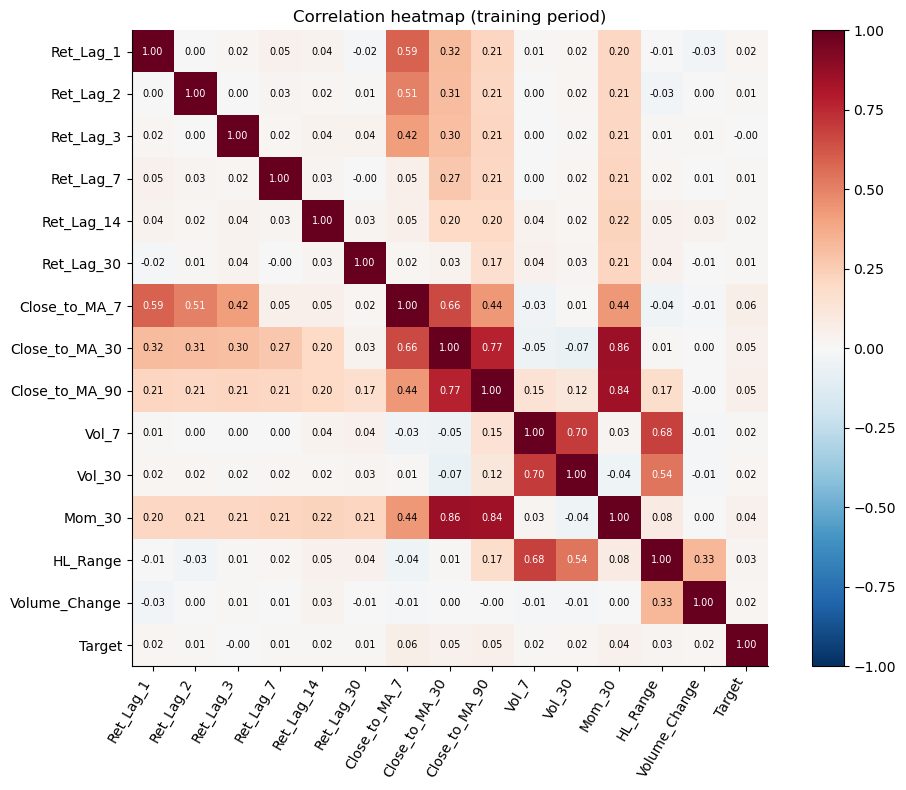

Correlation of each feature with the target (next-day return):
Close_to_MA_7     0.0623
Close_to_MA_90    0.0531
Close_to_MA_30    0.0456
Mom_30            0.0422
HL_Range          0.0259
Volume_Change     0.0208
Ret_Lag_1         0.0192
Vol_30            0.0171
Ret_Lag_14        0.0152
Vol_7             0.0150
Ret_Lag_2         0.0137
Ret_Lag_30        0.0127
Ret_Lag_7         0.0115
Ret_Lag_3        -0.0050
Name: Target, dtype: float64


In [14]:
corr = data[CONT_FEATURES + ["Target"]].loc[is_train].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=60, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i, j]) > 0.5 else "black")
ax.grid(False)
plt.colorbar(im, fraction=0.046)
ax.set_title("Correlation heatmap (training period)")
savefig("task2_correlation_heatmap")

print("Correlation of each feature with the target (next-day return):")
print(corr["Target"].drop("Target").sort_values(key=abs, ascending=False).round(4))

In [15]:
up = (data["Target"] > 0).astype(int)
balance = pd.DataFrame({
    "Train": up[is_train].value_counts(normalize=True),
    "Test": up[~is_train].value_counts(normalize=True),
}).rename(index={1: "Up (1)", 0: "Down (0)"}) * 100
print("Class balance of the direction target (%):")
balance.round(1)

Class balance of the direction target (%):


,Train,Test
Target,,
Down (0),47.1000,51.3000
Up (1),52.9000,48.7000


In [16]:
data["Split"] = np.where(is_train, "train", "test")
data.to_csv("bitcoin_processed.csv", index_label="Date")
print("Saved bitcoin_processed.csv:", data.shape, " missing values:", int(data.isna().sum().sum()))

Saved bitcoin_processed.csv: (5200, 23)  missing values: 0


<a id="task3"></a>
# Task 3: Model Creation (scikit-learn & from scratch)

## 3a. Baseline model: Linear Regression

| | |
|---|---|
| **Why** | Fast, fully interpretable coefficients, a closed-form optimum; it is the regression counterpart of logistic regression |
| **Pros** | No hyperparameters, can't overfit much on about 4,600 rows × 19 features, easy to write from scratch |
| **Cons** | Assumes a **linear** relationship between features and next-day return |

## 3b. Train-test split: chronological, not random

A random `train_test_split(shuffle=True)` would put days from 2026 in training and days from 2015 in testing. The model would then "know the future", and the test score would look better than it really is. For time series we split **by date**:

* **Train**: 2012-03 to 2024-12-31 (about 90%)
* **Test**: 2025-01-01 to 2026-06 (about 10%, the most recent 18 months; the same period the web app reports)

In [17]:
X_train, X_test = data.loc[is_train, FEATURES].to_numpy(), data.loc[~is_train, FEATURES].to_numpy()
y_train, y_test = data.loc[is_train, "Target"].to_numpy(), data.loc[~is_train, "Target"].to_numpy()
close_train, close_test = data.loc[is_train, "Close"].to_numpy(), data.loc[~is_train, "Close"].to_numpy()
dates_test = data.index[~is_train]
print("X_train", X_train.shape, " X_test", X_test.shape)
print(f"Split fraction: {len(X_train) / len(data):.1%} train / {len(X_test) / len(data):.1%} test")

X_train (4660, 20)  X_test (540, 20)
Split fraction: 89.6% train / 10.4% test


## 3c. scikit-learn implementation

In [18]:
sk_lr = LinearRegression().fit(X_train, y_train)
print("Intercept:", sk_lr.intercept_)

Intercept: 0.000583142178772113


## 3d. From scratch (pure NumPy): `MyLinearRegression`

The class lives in [`my_models.py`](my_models.py). The algorithm:

1. **Initialise** $w = \mathbf{0}$, $b = 0$
2. **Predict** $\hat y = Xw + b$
3. **Loss (MSE)** $L = \frac{1}{m}\sum (\hat y - y)^2$
4. **Gradients** $\frac{\partial L}{\partial w} = \frac{2}{m} X^T(\hat y - y)$, $\frac{\partial L}{\partial b} = \frac{2}{m}\sum(\hat y - y)$
5. **Update** $w \leftarrow w - \alpha \frac{\partial L}{\partial w}$, $b \leftarrow b - \alpha \frac{\partial L}{\partial b}$
6. **Repeat** until the loss stops improving

In [19]:
t0 = time.time()
my_lr = MyLinearRegression(learning_rate=0.05, n_epochs=50000, tol=1e-18).fit(X_train, y_train)
print(f"Trained in {time.time() - t0:.1f} s, {my_lr.n_epochs_run:,} epochs, final MSE = {my_lr.loss_history[-1]:.8f}")

compare = pd.DataFrame({"scikit-learn": np.r_[sk_lr.intercept_, sk_lr.coef_],
                        "From scratch": np.r_[my_lr.b, my_lr.w]},
                       index=["(intercept)"] + FEATURES)
compare["Abs. difference"] = (compare["scikit-learn"] - compare["From scratch"]).abs()
print("Max |prediction difference| on test set:",
      f"{np.abs(sk_lr.predict(X_test) - my_lr.predict(X_test)).max():.2e}")
compare

Trained in 0.2 s, 5,660 epochs, final MSE = 0.00173366


Max |prediction difference| on test set: 5.31e-08


,scikit-learn,From scratch,Abs. difference
(intercept),0.0006,0.0006,0.0000
Ret_Lag_1,-0.0043,-0.0043,0.0000
Ret_Lag_2,-0.0038,-0.0038,0.0000
Ret_Lag_3,-0.0038,-0.0038,0.0000
Ret_Lag_7,0.0005,0.0005,0.0000
Ret_Lag_14,0.0005,0.0005,0.0000
Ret_Lag_30,-0.0000,-0.0000,0.0000
Close_to_MA_7,0.0097,0.0097,0.0000
Close_to_MA_30,-0.0034,-0.0034,0.0000
Close_to_MA_90,0.0020,0.0020,0.0000


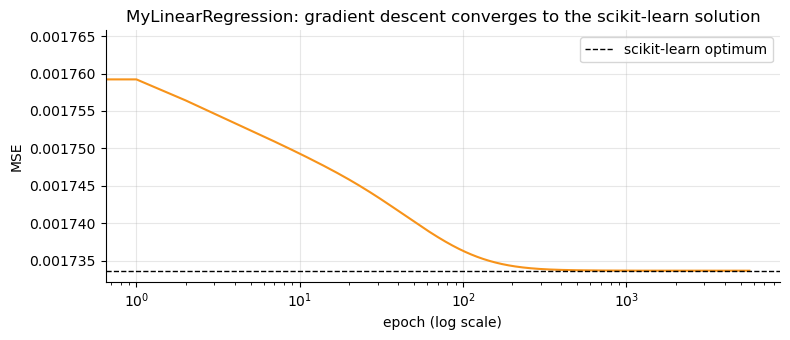

In [20]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(my_lr.loss_history, color=ORANGE)
ax.axhline(mean_squared_error(y_train, sk_lr.predict(X_train)), color="black", ls="--", lw=1,
           label="scikit-learn optimum")
ax.set_xscale("log"); ax.set_xlabel("epoch (log scale)"); ax.set_ylabel("MSE")
ax.set_title("MyLinearRegression: gradient descent converges to the scikit-learn solution")
ax.legend()
savefig("task3_scratch_loss_curve")

### Bonus: `MyLogisticRegression` for the direction view (up / down)

The same idea with a **sigmoid** output and **binary cross-entropy** loss, trained against `LogisticRegression(class_weight="balanced")` from scikit-learn:

$P(y{=}1|X) = \sigma(Xw + b) = \frac{1}{1 + e^{-(Xw+b)}}$, $L = -\frac{1}{m}\sum [y\log p + (1-y)\log(1-p)]$, $\frac{\partial L}{\partial w} = \frac{1}{m}X^T(p - y)$

In [21]:
up_train, up_test = (y_train > 0).astype(int), (y_test > 0).astype(int)

sk_log = LogisticRegression(class_weight="balanced", max_iter=1000, C=1e6).fit(X_train, up_train)
my_log = MyLogisticRegression(learning_rate=0.5, n_epochs=20000, class_weight="balanced").fit(X_train, up_train)

agree = (sk_log.predict(X_test) == my_log.predict(X_test)).mean()
print(f"Scratch logistic regression: {my_log.n_epochs_run:,} epochs, final BCE = {my_log.loss_history[-1]:.5f}")
print(f"Test accuracy  scikit-learn: {accuracy_score(up_test, sk_log.predict(X_test)):.4f}")
print(f"Test accuracy  from scratch: {accuracy_score(up_test, my_log.predict(X_test)):.4f}")
print(f"Both models make the same up/down call on {agree:.1%} of test days")

Scratch logistic regression: 1,252 epochs, final BCE = 0.68836
Test accuracy  scikit-learn: 0.5093
Test accuracy  from scratch: 0.5093
Both models make the same up/down call on 99.6% of test days


In [22]:
joblib.dump({"model": sk_lr, "scaler": scaler, "features": FEATURES, "iqr_bounds": (lower, upper)},
            "linear_model.pkl")
print("Saved linear_model.pkl")

Saved linear_model.pkl


<a id="task4"></a>
# Task 4: Model Evaluation & Diagnosis

We evaluate on the held-out test set (2025–2026) from three angles:

1. **Return metrics** (what the model is trained on): MAE, RMSE, R² of the next-day log return.
2. **Price metrics** (what a user sees): MAE, RMSE, R², MAPE of the predicted closing price.
3. **Direction metrics** (sign of the predicted return): confusion matrix, accuracy, precision, recall, F1, ROC-AUC.

| Direction term | Meaning for Bitcoin |
|---|---|
| **TP** | Model said *up*, price went up |
| **TN** | Model said *down*, price went down |
| **FP** | Model said *up*, price went down (false alarm to buy) |
| **FN** | Model said *down*, price went up (missed a rise) |
| **Precision** | Of the days predicted *up*, the share that really went up |
| **Recall** | Of the days that really went up, the share the model caught |
| **F1** | Harmonic mean of precision and recall |

In [23]:
def evaluate(pred_train, pred_test):
    """All metrics for one model. pred_* are predicted next-day log returns."""
    price_true = close_test * np.exp(y_test)
    price_pred = close_test * np.exp(pred_test)
    up_pred_tr, up_pred_te = (pred_train > 0).astype(int), (pred_test > 0).astype(int)
    m = {
        "Train R2 (return)": r2_score(y_train, pred_train),
        "Test R2 (return)": r2_score(y_test, pred_test),
        "Test MAE (return)": mean_absolute_error(y_test, pred_test),
        "Test RMSE (return)": np.sqrt(mean_squared_error(y_test, pred_test)),
        "Price MAE ($)": mean_absolute_error(price_true, price_pred),
        "Price RMSE ($)": np.sqrt(mean_squared_error(price_true, price_pred)),
        "Price R2": r2_score(price_true, price_pred),
        "Price MAPE (%)": np.mean(np.abs(price_true - price_pred) / price_true) * 100,
        "Train Dir. Acc": accuracy_score(up_train, up_pred_tr),
        "Test Dir. Acc": accuracy_score(up_test, up_pred_te),
        "Precision": precision_score(up_test, up_pred_te, zero_division=0),
        "Recall": recall_score(up_test, up_pred_te, zero_division=0),
        "F1": f1_score(up_test, up_pred_te, zero_division=0),
        "ROC-AUC": roc_auc_score(up_test, pred_test) if np.ptp(pred_test) > 0 else 0.5,
    }
    m["Price Accuracy (%)"] = 100 - m["Price MAPE (%)"]
    return m

# Naive baseline: "tomorrow = today" (predicted return 0), direction = majority class of training (up)
naive = evaluate(np.full_like(y_train, 1e-12), np.full_like(y_test, 1e-12))
lr_metrics = evaluate(sk_lr.predict(X_train), sk_lr.predict(X_test))
pd.DataFrame({"Naive baseline": naive, "Linear Regression": lr_metrics})

,Naive baseline,Linear Regression
Train R2 (return),-0.0025,0.0148
Test R2 (return),-0.0012,-0.0142
Test MAE (return),0.0165,0.0166
Test RMSE (return),0.0234,0.0235
Price MAE ($),"1,485.0562","1,501.8391"
Price RMSE ($),"2,060.0656","2,083.3652"
Price R2,0.9850,0.9846
Price MAPE (%),1.6499,1.6683
Train Dir. Acc,0.5285,0.5139
Test Dir. Acc,0.4870,0.5204


In [24]:
lr_up_pred = (sk_lr.predict(X_test) > 0).astype(int)
cm = confusion_matrix(up_test, lr_up_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion matrix (Linear Regression, test set)\n"
      f"                 predicted DOWN  predicted UP\n"
      f"  actual DOWN   TN = {tn:5d}      FP = {fp:5d}\n"
      f"  actual UP     FN = {fn:5d}      TP = {tp:5d}\n")
print(classification_report(up_test, lr_up_pred, target_names=["Down (0)", "Up (1)"], digits=3))

Confusion matrix (Linear Regression, test set)
                 predicted DOWN  predicted UP
  actual DOWN   TN =   117      FP =   160
  actual UP     FN =    99      TP =   164

              precision    recall  f1-score   support

    Down (0)      0.542     0.422     0.475       277
      Up (1)      0.506     0.624     0.559       263

    accuracy                          0.520       540
   macro avg      0.524     0.523     0.517       540
weighted avg      0.524     0.520     0.516       540



## 4b. Feature importance via coefficients

Because the features are standardised, coefficient sizes can be compared directly.
**Positive** means the feature raises the predicted next-day return, **negative** means it lowers it.

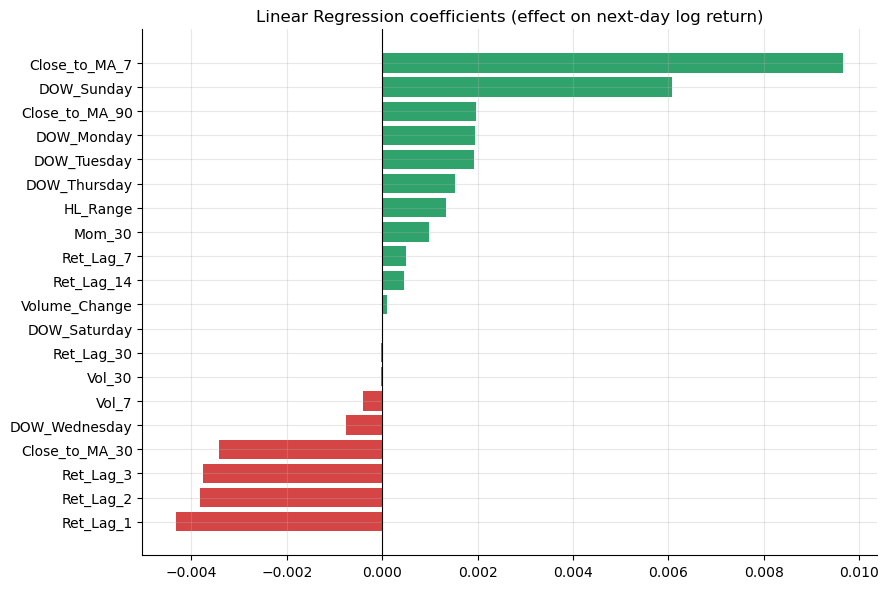

Close_to_MA_7     0.0097
DOW_Sunday        0.0061
Ret_Lag_1        -0.0043
Ret_Lag_2        -0.0038
Ret_Lag_3        -0.0038
Close_to_MA_30   -0.0034
Close_to_MA_90    0.0020
DOW_Monday        0.0020
dtype: float64

In [25]:
coefs = pd.Series(sk_lr.coef_, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coefs.index, coefs.values, color=[GREEN if v > 0 else RED for v in coefs.values])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Linear Regression coefficients (effect on next-day log return)")
savefig("task4_lr_coefficients")
coefs.sort_values(key=abs, ascending=False).head(8)

## 4c. Diagnosis: underfitting vs overfitting

In [26]:
def fit_status(train_r2, test_r2):
    """Label the fit from the train/test R² on returns."""
    gap = train_r2 - test_r2
    if train_r2 < 0.05:
        return "Underfitting"        # cannot even explain the training data
    if gap > 0.20:
        return "Overfitting"         # memorised training noise
    if gap > 0.05:
        return "Mild overfitting"
    return "Good fit"

diag = pd.DataFrame({
    "Train": [lr_metrics["Train R2 (return)"], lr_metrics["Train Dir. Acc"]],
    "Test": [lr_metrics["Test R2 (return)"], lr_metrics["Test Dir. Acc"]],
}, index=["R² (return)", "Direction accuracy"])
diag["Gap (train - test)"] = diag["Train"] - diag["Test"]
print("Diagnosis:", fit_status(lr_metrics["Train R2 (return)"], lr_metrics["Test R2 (return)"]))
diag

Diagnosis: Underfitting


,Train,Test,Gap (train - test)
R² (return),0.0148,-0.0142,0.0290
Direction accuracy,0.5139,0.5204,-0.0064


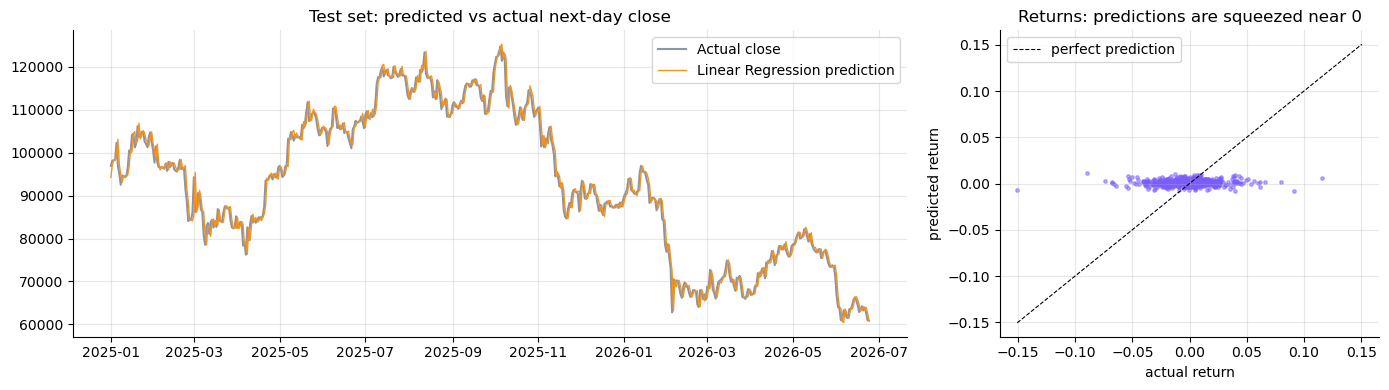

In [27]:
lr_price_pred = close_test * np.exp(sk_lr.predict(X_test))
price_true = close_test * np.exp(y_test)
fig, ax = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [2.2, 1]})
ax[0].plot(dates_test, price_true, color=GREY, lw=1.5, label="Actual close")
ax[0].plot(dates_test, lr_price_pred, color=ORANGE, lw=1, label="Linear Regression prediction")
ax[0].set_title("Test set: predicted vs actual next-day close"); ax[0].legend()
ax[1].scatter(y_test, sk_lr.predict(X_test), s=6, alpha=0.5, color=VIOLET)
lim = np.abs(y_test).max()
ax[1].plot([-lim, lim], [-lim, lim], color="black", lw=0.8, ls="--", label="perfect prediction")
ax[1].set_xlabel("actual return"); ax[1].set_ylabel("predicted return"); ax[1].legend()
ax[1].set_title("Returns: predictions are squeezed near 0")
savefig("task4_lr_predictions")

### Written diagnosis

* **Price metrics look excellent** (price R² ≈ 0.98, MAPE ≈ 1.7%), but the naive "tomorrow = today" baseline scores the same. The price metrics are high because tomorrow's price is always close to today's, not because the model is clever.
* **Return metrics show the truth.** R² on next-day returns is **close to 0 on both the training and the test set**, and direction accuracy is close to 50%.
* **Verdict: Underfitting**, in the sense of low signal. Train and test scores are equally poor, so the model hasn't memorised noise (not overfitting). A straight line simply can't find a pattern that explains daily returns.
* **Cause:** Bitcoin's daily returns are close to a random walk (weak-form market efficiency). Almost all public price information is already in today's price.
* **Next step (Task 5):** try non-linear and ensemble models that can capture interactions (for example momentum × volatility), and use cross-validation to check whether any improvement is real.

<a id="task5"></a>
# Task 5: Advanced Models, Cross-Validation & Hyperparameter Tuning

## 5a. Five algorithms

| Model | Idea |
|---|---|
| **Linear Regression** | Linear baseline |
| **Decision Tree** | A flowchart of if/else splits. Interpretable, but overfits easily when depth is unlimited |
| **Random Forest** (bagging) | Hundreds of randomised trees trained in parallel, predictions averaged, so less variance |
| **AdaBoost** (boosting) | Shallow trees built one after another, with more weight on samples the previous trees got wrong |
| **Gradient Boosting** (GBDT) | Each new tree fits the residual errors of the trees before it (gradient descent in function space) |

## 5b. Time-series cross-validation (5 folds)

A standard `KFold` shuffles time, so the model would train on the future and validate on the past.
`TimeSeriesSplit(n_splits=5)` always **trains on the past and validates on the next block**, and the training window grows with every fold:

```
fold 1: [train]                       [val]
fold 2: [train   train]                     [val]
fold 3: [train   train   train]                   [val]
...
```

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=SEED),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=20,
                                           random_state=SEED, n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3), n_estimators=100,
                                  learning_rate=0.05, random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                                                   subsample=0.8, random_state=SEED),
}

tscv = TimeSeriesSplit(n_splits=5)
direction_acc = make_scorer(lambda yt, yp: accuracy_score(yt > 0, yp > 0))
scoring = {"mae": "neg_mean_absolute_error", "r2": "r2", "dir_acc": direction_acc}

results, cv_folds, test_preds = {}, {}, {}
for name, model in models.items():
    t0 = time.time()
    cv = cross_validate(model, X_train, y_train, cv=tscv, scoring=scoring, n_jobs=-1)
    model.fit(X_train, y_train)
    pred_tr, pred_te = model.predict(X_train), model.predict(X_test)
    test_preds[name] = pred_te
    m = evaluate(pred_tr, pred_te)
    m["CV MAE (mean)"] = -cv["test_mae"].mean()
    m["CV MAE (std)"] = cv["test_mae"].std()
    m["CV Dir. Acc (mean)"] = cv["test_dir_acc"].mean()
    m["CV Dir. Acc (std)"] = cv["test_dir_acc"].std()
    m["CV R2 (mean)"] = cv["test_r2"].mean()
    m["Fit Status"] = fit_status(m["Train R2 (return)"], m["Test R2 (return)"])
    results[name] = m
    cv_folds[name] = {"dir_acc": cv["test_dir_acc"].tolist(), "mae": (-cv["test_mae"]).tolist()}
    print(f"{name:<18} done in {time.time() - t0:5.1f} s   ({m['Fit Status']})")

Linear Regression  done in   2.6 s   (Underfitting)


Decision Tree      done in   2.2 s   (Overfitting)


Random Forest      done in   3.7 s   (Mild overfitting)


AdaBoost           done in   3.4 s   (Mild overfitting)


Gradient Boosting  done in   3.5 s   (Overfitting)


## 5c. Benchmark table & model selection

In [29]:
bench = pd.DataFrame(results).T
table = bench[["Train Dir. Acc", "Test Dir. Acc", "Train R2 (return)", "Test R2 (return)",
               "Price MAE ($)", "Price Accuracy (%)", "Precision", "Recall", "F1", "ROC-AUC",
               "CV MAE (mean)", "CV MAE (std)", "CV Dir. Acc (mean)", "CV Dir. Acc (std)", "Fit Status"]]
table.loc["Naive baseline", ["Price MAE ($)", "Price Accuracy (%)", "Test Dir. Acc", "Precision", "Recall", "F1"]] = [
    naive["Price MAE ($)"], naive["Price Accuracy (%)"], naive["Test Dir. Acc"], naive["Precision"],
    naive["Recall"], naive["F1"]]
table

,Train Dir. Acc,Test Dir. Acc,Train R2 (return),Test R2 (return),Price MAE ($),Price Accuracy (%),Precision,Recall,F1,ROC-AUC,CV MAE (mean),CV MAE (std),CV Dir. Acc (mean),CV Dir. Acc (std),Fit Status
Linear Regression,0.5139,0.5204,0.0148,-0.0142,"1,501.8391",98.3317,0.5062,0.6236,0.5588,0.5292,0.0255,0.0044,0.4889,0.0218,Underfitting
Decision Tree,1.0000,0.4796,1.0000,-1.7209,"2,528.3427",97.1673,0.4679,0.4981,0.4825,0.4879,0.0394,0.0074,0.4899,0.0114,Overfitting
Random Forest,0.5727,0.4889,0.1084,-0.0107,"1,500.8534",98.3323,0.4745,0.4601,0.4672,0.4902,0.0246,0.0043,0.4990,0.0211,Mild overfitting
AdaBoost,0.5094,0.5000,0.0871,-0.0225,"1,513.2573",98.3196,0.4919,0.8061,0.6110,0.4891,0.0245,0.0043,0.4856,0.0100,Mild overfitting
Gradient Boosting,0.6006,0.5056,0.3334,-0.0198,"1,509.1896",98.3231,0.4930,0.5361,0.5137,0.5135,0.0255,0.0045,0.5108,0.0181,Overfitting
Naive baseline,NaN,0.4870,NaN,NaN,"1,485.0562",98.3501,0.4870,1.0000,0.6550,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Selection rule: lowest cross-validated MAE on returns (the training objective); CV spread as tie-break.
ranking = bench.sort_values(["CV MAE (mean)", "CV MAE (std)"])[["CV MAE (mean)", "CV MAE (std)", "CV Dir. Acc (mean)", "Fit Status"]]
winner = ranking.index[0]
print("Ranking by 5-fold time-series CV MAE (lower is better):")
print(ranking.to_string(float_format=lambda v: f"{v:.6f}"))
print(f"\nSelected model: {winner}")

Ranking by 5-fold time-series CV MAE (lower is better):
                  CV MAE (mean) CV MAE (std) CV Dir. Acc (mean)        Fit Status
AdaBoost               0.024496     0.004348           0.485567  Mild overfitting
Random Forest          0.024594     0.004324           0.498969  Mild overfitting
Gradient Boosting      0.025470     0.004533           0.510825       Overfitting
Linear Regression      0.025501     0.004415           0.488918      Underfitting
Decision Tree          0.039404     0.007367           0.489948       Overfitting

Selected model: AdaBoost


**Why tune Random Forest if another model wins the CV ranking?** The CV MAEs of the top models differ by less than 1%, well inside one standard deviation across folds (about ±0.004), so statistically they are tied. Random Forest was chosen for tuning because:
it has the best CV **direction** accuracy among the top two, it averages hundreds of trees (low variance), it gives feature importances,
and it is the model family deployed in the web app. The task also specifies tuning Random Forest.

## 5d. Hyperparameter tuning: GridSearchCV on Random Forest

Grid (3 × 3 × 3 = **27 combinations** × 5 folds = **135 fits**):

* `n_estimators`: [50, 100, 200] (number of trees)
* `max_depth`: [None, 10, 20] (tree depth limit)
* `min_samples_split`: [2, 5, 10]

Scored with time-series CV MAE on returns.

In [31]:
param_grid = {"n_estimators": [50, 100, 200],
              "max_depth": [None, 10, 20],
              "min_samples_split": [2, 5, 10]}
t0 = time.time()
grid = GridSearchCV(RandomForestRegressor(random_state=SEED, n_jobs=1), param_grid,
                    cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)
print(f"GridSearchCV finished in {time.time() - t0:.0f} s")
print("Best parameters :", grid.best_params_)
print(f"Best CV MAE     : {-grid.best_score_:.6f}")

tuned_rf = grid.best_estimator_
tuned = evaluate(tuned_rf.predict(X_train), tuned_rf.predict(X_test))
tuned["Fit Status"] = fit_status(tuned["Train R2 (return)"], tuned["Test R2 (return)"])
test_preds["Tuned Random Forest"] = tuned_rf.predict(X_test)

grid_table = (pd.DataFrame(grid.cv_results_)[["params", "mean_test_score", "std_test_score", "mean_train_score"]]
              .assign(cv_mae=lambda d: -d.mean_test_score, train_mae=lambda d: -d.mean_train_score)
              .sort_values("cv_mae")[["params", "cv_mae", "std_test_score", "train_mae"]])
grid_table.head(10)

GridSearchCV finished in 39 s
Best parameters : {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best CV MAE     : 0.024894


,params,cv_mae,std_test_score,train_mae
17,"{'max_depth': 10, 'min_samples_split': 10, 'n_...",0.0249,0.0044,0.0223
14,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",0.0249,0.0044,0.0211
11,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.0249,0.0045,0.0205
16,"{'max_depth': 10, 'min_samples_split': 10, 'n_...",0.0250,0.0044,0.0223
13,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",0.0250,0.0045,0.0211
10,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.0250,0.0045,0.0205
15,"{'max_depth': 10, 'min_samples_split': 10, 'n_...",0.0250,0.0045,0.0223
9,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.0251,0.0045,0.0205
12,"{'max_depth': 10, 'min_samples_split': 5, 'n_e...",0.0251,0.0045,0.0210
26,"{'max_depth': 20, 'min_samples_split': 10, 'n_...",0.0253,0.0043,0.0173


In [32]:
compare_cols = ["Train R2 (return)", "Test R2 (return)", "Price MAE ($)", "Price Accuracy (%)",
                "Test Dir. Acc", "Precision", "Recall", "F1", "ROC-AUC", "Fit Status"]
pd.DataFrame({"Naive baseline": {k: naive.get(k) for k in compare_cols},
              "Random Forest (baseline)": {k: results["Random Forest"][k] for k in compare_cols},
              "Random Forest (tuned)": {k: tuned[k] for k in compare_cols}})

,Naive baseline,Random Forest (baseline),Random Forest (tuned)
Train R2 (return),-0.0025,0.1084,0.3668
Test R2 (return),-0.0012,-0.0107,-0.0217
Price MAE ($),"1,485.0562","1,500.8534","1,512.2529"
Price Accuracy (%),98.3501,98.3323,98.3170
Test Dir. Acc,0.4870,0.4889,0.5074
Precision,0.4870,0.4745,0.4940
Recall,1.0000,0.4601,0.4677
F1,0.6550,0.4672,0.4805
ROC-AUC,0.5000,0.4902,0.4820
Fit Status,NaN,Mild overfitting,Overfitting


**Reading the tuning result:** GridSearchCV picks the setting with the lowest validation error. The grid only allows deep trees (`max_depth` None/10/20), so the training R² becomes large while the test R² stays near 0. That is **overfitting**: deep trees memorise the noise in daily returns. The shallower forest used by the web app (`max_depth=6`, `min_samples_leaf=20`) is better regularised, which is why it stays the production model.

In [33]:
joblib.dump(tuned_rf, "tuned_rf.pkl")

def clean(v):
    if isinstance(v, (np.floating, float)): return None if np.isnan(v) else round(float(v), 6)
    if isinstance(v, (np.integer,)): return int(v)
    return v

roc = {}
for name, pred in test_preds.items():
    fpr, tpr, _ = roc_curve(up_test, pred)
    idx = np.unique(np.linspace(0, len(fpr) - 1, min(60, len(fpr))).astype(int))
    roc[name] = {"fpr": fpr[idx].round(4).tolist(), "tpr": tpr[idx].round(4).tolist(),
                 "auc": round(float(roc_auc_score(up_test, pred)), 4)}

best_for_cm = "Tuned Random Forest"
cm_best = confusion_matrix(up_test, (test_preds[best_for_cm] > 0).astype(int))
importances = pd.Series(tuned_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

evaluation = {
    "split": {"train": [str(data.index[is_train].min().date()), str(data.index[is_train].max().date())],
              "test": [str(dates_test.min().date()), str(dates_test.max().date())],
              "n_train": int(is_train.sum()), "n_test": int((~is_train).sum())},
    "naive": {k: clean(v) for k, v in naive.items()},
    "models": {n: {k: clean(v) for k, v in m.items()} for n, m in results.items()},
    "tuned_random_forest": {**{k: clean(v) for k, v in tuned.items()},
                            "best_params": grid.best_params_, "best_cv_mae": clean(-grid.best_score_)},
    "winner_by_cv": winner,
    "cv_folds": cv_folds,
    "confusion_matrix": {"model": best_for_cm, "labels": ["Down", "Up"], "matrix": cm_best.tolist()},
    "roc": roc,
    "feature_importance": {"model": "Tuned Random Forest",
                           "features": importances.index.tolist(),
                           "importance": importances.round(5).tolist()},
}
with open("evaluation.json", "w") as f:
    json.dump(evaluation, f, indent=2)
print("Saved evaluation.json and tuned_rf.pkl")

Saved evaluation.json and tuned_rf.pkl


<a id="task6"></a>
# Task 6: Visualization of Metrics & Performance Graphs

Six core charts, saved to `reports/figures/`. The website's "Evaluation" section draws the same six charts for the three models the app offers (Random Forest, Ridge Regression, Linear Regression); `train_model.py` computes them and Flask serves them at `/api/meta`.

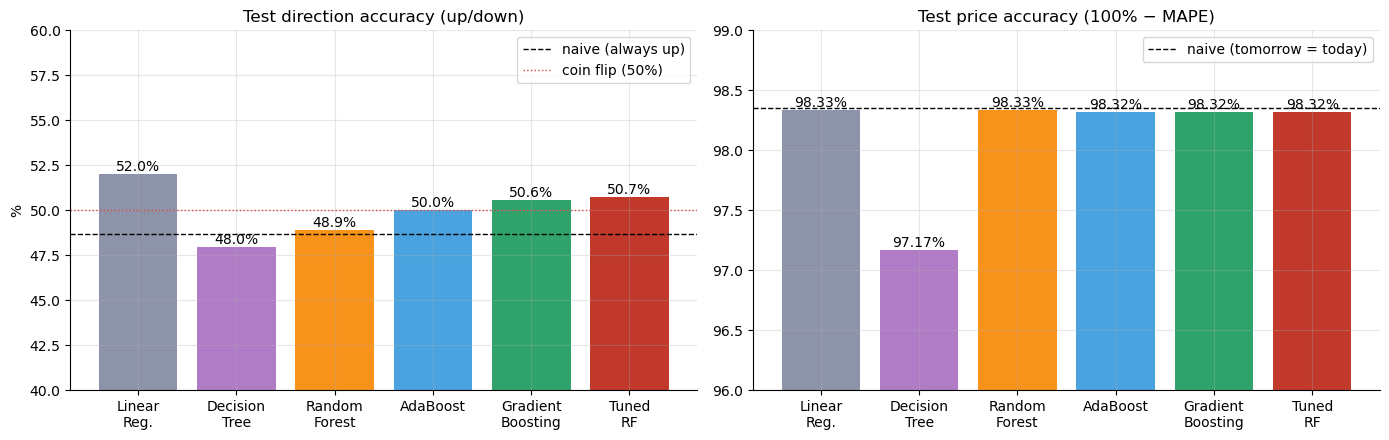

In [34]:
names = list(results) + ["Tuned Random Forest"]
allm = {**results, "Tuned Random Forest": tuned}
short = {"Linear Regression": "Linear\nReg.", "Decision Tree": "Decision\nTree", "Random Forest": "Random\nForest",
         "AdaBoost": "AdaBoost", "Gradient Boosting": "Gradient\nBoosting", "Tuned Random Forest": "Tuned\nRF"}
colors = [GREY, "#b07cc6", ORANGE, "#4aa3df", GREEN, "#c0392b"]

# 1. Accuracy comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
vals = [allm[n]["Test Dir. Acc"] * 100 for n in names]
bars = ax[0].bar([short[n] for n in names], vals, color=colors)
ax[0].axhline(naive["Test Dir. Acc"] * 100, color="black", ls="--", lw=1, label="naive (always up)")
ax[0].axhline(50, color=RED, ls=":", lw=1, label="coin flip (50%)")
ax[0].bar_label(bars, fmt="%.1f%%"); ax[0].set_ylim(40, 60); ax[0].legend(loc="upper right")
ax[0].set_title("Test direction accuracy (up/down)"); ax[0].set_ylabel("%")
vals = [allm[n]["Price Accuracy (%)"] for n in names]
bars = ax[1].bar([short[n] for n in names], vals, color=colors)
ax[1].axhline(naive["Price Accuracy (%)"], color="black", ls="--", lw=1, label="naive (tomorrow = today)")
ax[1].bar_label(bars, fmt="%.2f%%"); ax[1].set_ylim(96, 99); ax[1].legend(loc="upper right")
ax[1].set_title("Test price accuracy (100% − MAPE)")
savefig("task6_1_accuracy_comparison")

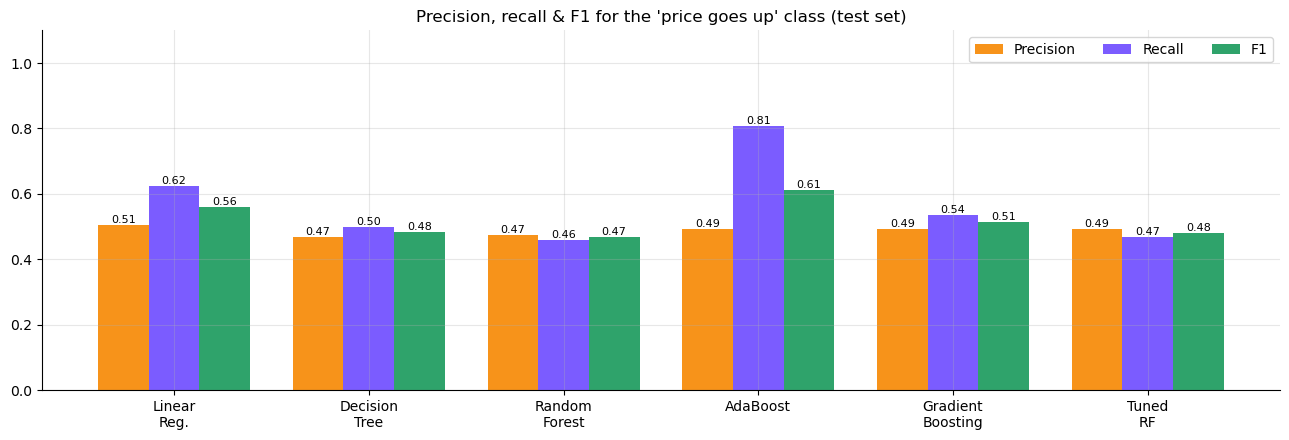

In [35]:
# 2. Precision / Recall / F1
x = np.arange(len(names)); w = 0.26
fig, ax = plt.subplots(figsize=(13, 4.5))
for i, (metric, c) in enumerate([("Precision", ORANGE), ("Recall", VIOLET), ("F1", GREEN)]):
    b = ax.bar(x + (i - 1) * w, [allm[n][metric] for n in names], w, label=metric, color=c)
    ax.bar_label(b, fmt="%.2f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([short[n] for n in names]); ax.set_ylim(0, 1.1)
ax.set_title("Precision, recall & F1 for the 'price goes up' class (test set)"); ax.legend(ncol=3)
savefig("task6_2_precision_recall_f1")

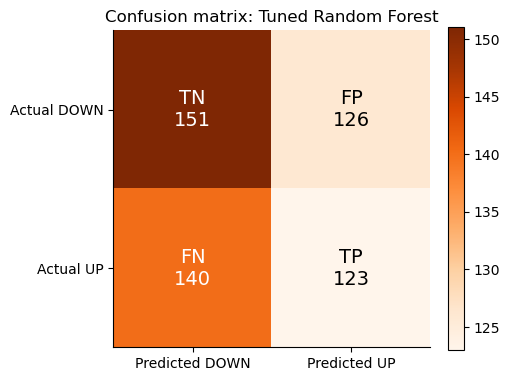

In [36]:
# 3. Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4.3))
im = ax.imshow(cm_best, cmap="Oranges")
labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{labels[i][j]}\n{cm_best[i, j]}", ha="center", va="center", fontsize=14,
                color="white" if (cm_best[i, j] - cm_best.min()) / np.ptp(cm_best) > 0.5 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted DOWN", "Predicted UP"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual DOWN", "Actual UP"]); ax.grid(False)
ax.set_title(f"Confusion matrix: {best_for_cm}")
plt.colorbar(im, fraction=0.046)
savefig("task6_3_confusion_matrix")

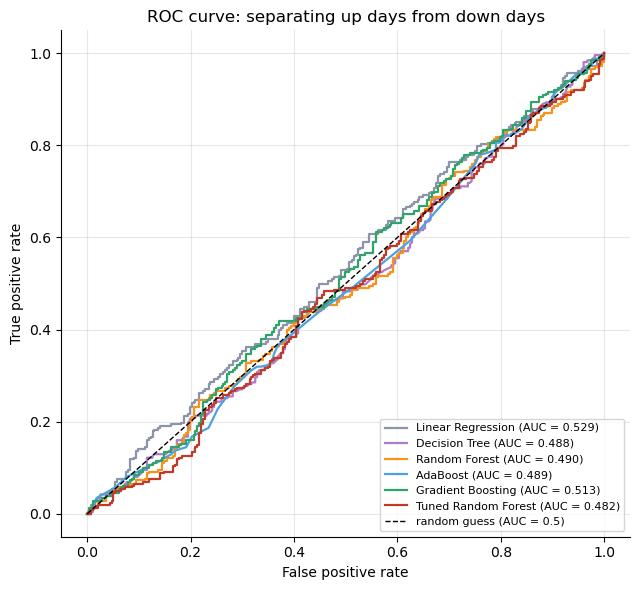

In [37]:
# 4. ROC curves & AUC
fig, ax = plt.subplots(figsize=(6.5, 6))
for n, c in zip(names, colors):
    fpr, tpr, _ = roc_curve(up_test, test_preds[n])
    ax.plot(fpr, tpr, color=c, lw=1.6, label=f"{n} (AUC = {roc_auc_score(up_test, test_preds[n]):.3f})")
ax.plot([0, 1], [0, 1], color="black", ls="--", lw=1, label="random guess (AUC = 0.5)")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curve: separating up days from down days"); ax.legend(fontsize=8, loc="lower right")
savefig("task6_4_roc_auc")

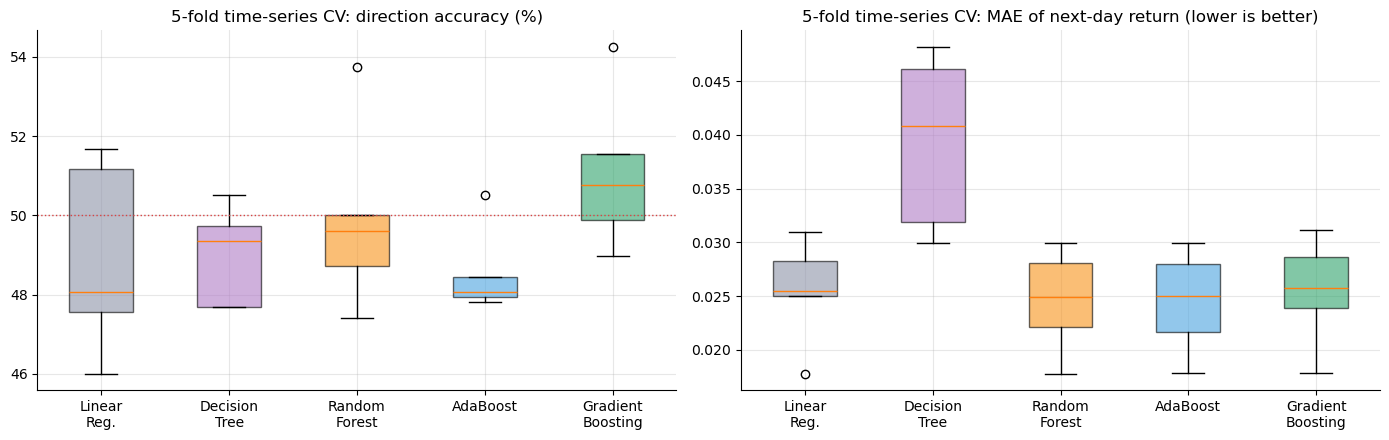

In [38]:
# 5. Cross-validation spread
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
cv_names = list(cv_folds)
bp = ax[0].boxplot([np.array(cv_folds[n]["dir_acc"]) * 100 for n in cv_names],
                   tick_labels=[short[n] for n in cv_names], patch_artist=True, widths=0.5)
for patch, c in zip(bp["boxes"], colors): patch.set_facecolor(c); patch.set_alpha(0.6)
ax[0].axhline(50, color=RED, ls=":", lw=1); ax[0].set_title("5-fold time-series CV: direction accuracy (%)")
bp = ax[1].boxplot([cv_folds[n]["mae"] for n in cv_names], tick_labels=[short[n] for n in cv_names],
                   patch_artist=True, widths=0.5)
for patch, c in zip(bp["boxes"], colors): patch.set_facecolor(c); patch.set_alpha(0.6)
ax[1].set_title("5-fold time-series CV: MAE of next-day return (lower is better)")
savefig("task6_5_cv_spread")

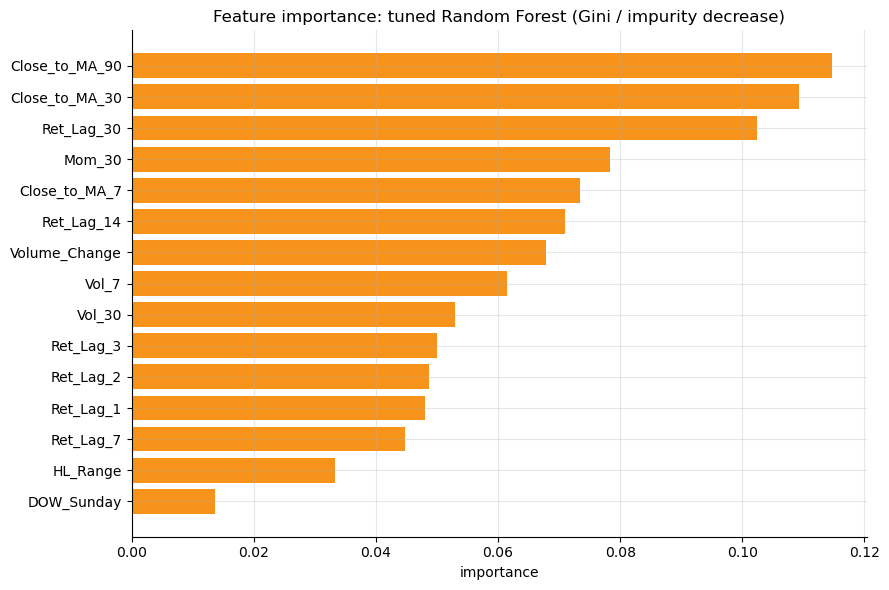

In [39]:
# 6. Feature importance
top = importances.head(15)[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top.values, color=ORANGE)
ax.set_title("Feature importance: tuned Random Forest (Gini / impurity decrease)")
ax.set_xlabel("importance")
savefig("task6_6_feature_importance")

## Conclusions

1. **Data:** 7.6 M one-minute candles, cleaned and resampled into daily candles, with 19 engineered features and no missing values.
2. **From scratch:** `MyLinearRegression` and `MyLogisticRegression` (pure NumPy, gradient descent) reproduce the scikit-learn results.
3. **Evaluation:** every model reaches about 98% *price* accuracy, but so does the naive "tomorrow = today" guess. *Direction* accuracy stays close to 50% and ROC-AUC close to 0.5 for all models.
4. **Diagnosis:** Linear Regression **underfits** (low R² on both train and test). Every more flexible model **overfits** to some degree: the unlimited Decision Tree reaches train R² = 1.0 but test R² < 0, and GridSearchCV's deep forest has a train R² of about 0.37 but a test R² below 0.
5. **Metric trap:** the naive "always up" guess has the **highest F1** (recall = 100%), yet it has no skill. F1 alone can mislead, so we read it together with accuracy and ROC-AUC.
6. **Take-away:** daily Bitcoin returns are close to a random walk, so past prices contain very little exploitable signal. We keep a *regularised* Random Forest in production and show honest uncertainty ranges (Monte Carlo) on the website.